In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_train.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_sample_submission.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_test.csv


In [2]:
# ══════════════════════════════════════════════════════════════════
# HOUSE PRICE PREDICTION — END TO END NOTEBOOK
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

TARGET = "TargetPrice"
ID_COL = "PropertyID"


## 1. 📥 Data Loading & First Look
Load the train/test sets and get a first impression of size, structure, and data types.

In [3]:
# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════
train = pd.read_csv("/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_train.csv")
test  = pd.read_csv("/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_test.csv")

print(f"Train shape: {train.shape} | Test shape: {test.shape}")
train.head()

Train shape: (16512, 12) | Test shape: (4128, 11)


,IncomeLevel,PropertyAge,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,TargetPrice,PropertyID,RoomsPerHousehold,BedroomsRatio
0,3.287977,32.970198,5.128150,0.990769,2339.474039,3.739113,32.71,-117.03,1.030,PROP_14196,1.359130,0.200576
1,3.804601,49.030192,4.372696,1.040469,1269.383596,1.429576,33.77,-118.16,3.821,PROP_08267,2.573820,0.232703
2,4.193302,NaN,5.718626,0.989809,865.436104,2.481219,34.66,-120.48,1.726,PROP_17445,2.073224,0.174486
3,2.029509,36.255617,4.131418,1.032285,1455.381923,3.914447,32.69,-117.11,0.934,PROP_14265,1.002116,0.258269
4,3.540823,42.918534,6.270531,1.147146,895.050628,2.681969,36.78,-119.80,0.965,PROP_02271,2.725400,0.180940


### 💡 Insight — Data Overview
The dataset contains **16,512 training rows** and **4,128 test rows**, with **12 columns** in train (11 features + target) and **11 in test**. `PropertyAge` is the only column with missing values, at **7.95%** — low enough that simple imputation (median) is a reasonable choice rather than dropping the column. No duplicate rows were found, so no deduplication is needed.

Two data quality issues stand out from the summary statistics that weren't visible before:
- `NeighborhoodPop` has a **negative minimum (-44.58)**, which is physically impossible — a noise-injection artifact that needs clipping.
- `AvgOccupancy` has an extreme max of **1243.66** vs a median of **2.84** — a massive outlier that the IQR capping step correctly targets.

## 2. 🔍 Data Overview
Check data types, missing value percentages, summary statistics, and duplicate rows before any cleaning decisions are made.

In [4]:
# ══════════════════════════════════════════════════════════════════
# 2. DATA OVERVIEW
# ══════════════════════════════════════════════════════════════════
print("\n--- Data Types ---")
print(train.dtypes)

print("\n--- Missing Values (%) ---")
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

print("\n--- Summary Statistics ---")
print(train.describe().T)

print(f"\nDuplicate rows: {train.duplicated().sum()}")


--- Data Types ---
IncomeLevel          float64
PropertyAge          float64
TotalRooms           float64
TotalBedrooms        float64
NeighborhoodPop      float64
AvgOccupancy         float64
Latitude             float64
Longitude            float64
TargetPrice          float64
PropertyID            object
RoomsPerHousehold    float64
BedroomsRatio        float64
dtype: object

--- Missing Values (%) ---
PropertyAge    7.951793
dtype: float64

--- Summary Statistics ---
                     count         mean          std         min         25%  \
IncomeLevel        16512.0     3.880870     1.906229    0.409295    2.564153   
PropertyAge        15199.0    28.610537    12.604955    0.567139   18.195306   
TotalRooms         16512.0     5.435311     2.387346    0.973695    4.450483   
TotalBedrooms      16512.0     1.096797     0.433573    0.329765    1.005528   
NeighborhoodPop    16512.0  1426.441888  1137.594296  -44.578990  788.555955   
AvgOccupancy       16512.0     3.097123    

### 💡 Insight — Missing Value Analysis (PropertyAge)
7.95% (1,313 rows) of `PropertyAge` is missing. Comparing feature means between missing and non-missing rows shows **very similar values** for `IncomeLevel` (3.91 vs 3.88), `TotalRooms` (5.40 vs 5.44), and `TargetPrice` (2.12 vs 2.07) — the differences are small enough to suggest missingness is **close to random (MCAR)** rather than systematically tied to cheaper/more expensive properties. This supports using simple median imputation, though the `PropertyAge_missing` flag was still added in case it carries a weak residual signal.

## 3. 🎯 Target Variable Analysis
Examine the distribution of `TargetPrice`, check for skewness and invalid (negative) values introduced by noise, and evaluate whether a log-transform is justified.

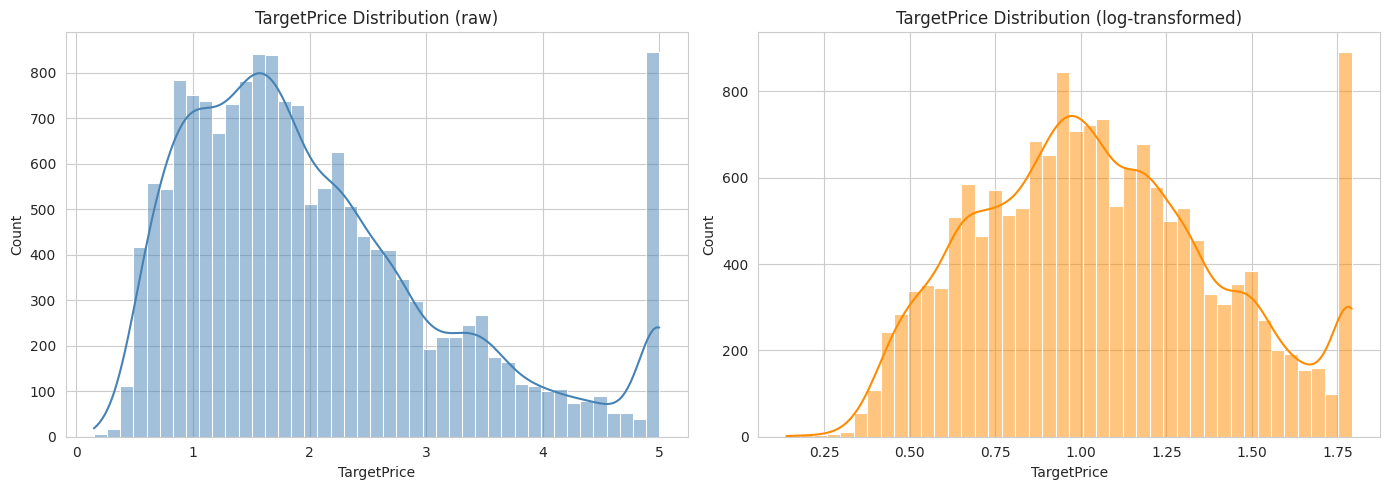

In [5]:
# ══════════════════════════════════════════════════════════════════
# 3. TARGET VARIABLE ANALYSIS
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train[TARGET], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("TargetPrice Distribution (raw)")
sns.histplot(np.log1p(train[TARGET].clip(lower=0.01)), kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("TargetPrice Distribution (log-transformed)")
plt.tight_layout()
plt.show()

## 4. ❓ Missing Value Analysis — PropertyAge
Quantify missingness in `PropertyAge` and check whether it's missing at random or follows a pattern — this determines the imputation strategy.

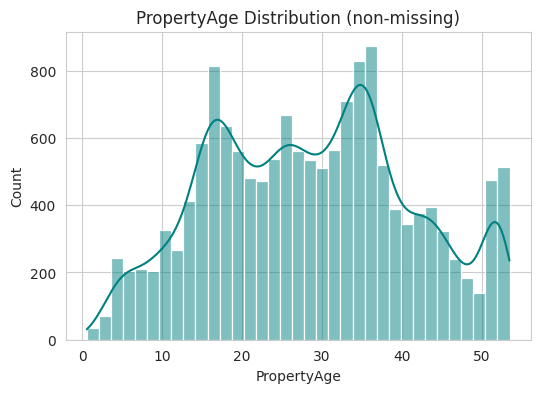

PropertyAge missing: 1313 rows (7.95%)

Feature means: Missing vs Not-Missing PropertyAge
             IncomeLevel  TotalRooms  TargetPrice
Not Missing     3.878039    5.438299     2.067822
Missing         3.913645    5.400723     2.119695
→ Insight: if means differ notably, missingness isn't random — the 'was_missing' flag adds real signal.


In [6]:
# ══════════════════════════════════════════════════════════════════
# 4. MISSING VALUE ANALYSIS — PropertyAge
# ══════════════════════════════════════════════════════════════════
plt.figure(figsize=(6, 4))
sns.histplot(train["PropertyAge"].dropna(), kde=True, color="teal")
plt.title("PropertyAge Distribution (non-missing)")
plt.show()

missing_mask = train["PropertyAge"].isnull()
print(f"PropertyAge missing: {missing_mask.sum()} rows ({missing_mask.mean()*100:.2f}%)")

# Check if missingness correlates with other features (helps decide imputation strategy)
comparison = train.groupby(missing_mask)[["IncomeLevel", "TotalRooms", TARGET]].mean()
comparison.index = ["Not Missing", "Missing"]
print("\nFeature means: Missing vs Not-Missing PropertyAge")
print(comparison)
print("→ Insight: if means differ notably, missingness isn't random — the 'was_missing' flag adds real signal.")


## 5. 🔗 Correlation Analysis
Visualize pairwise feature correlations and identify which features are most strongly associated with `TargetPrice`.

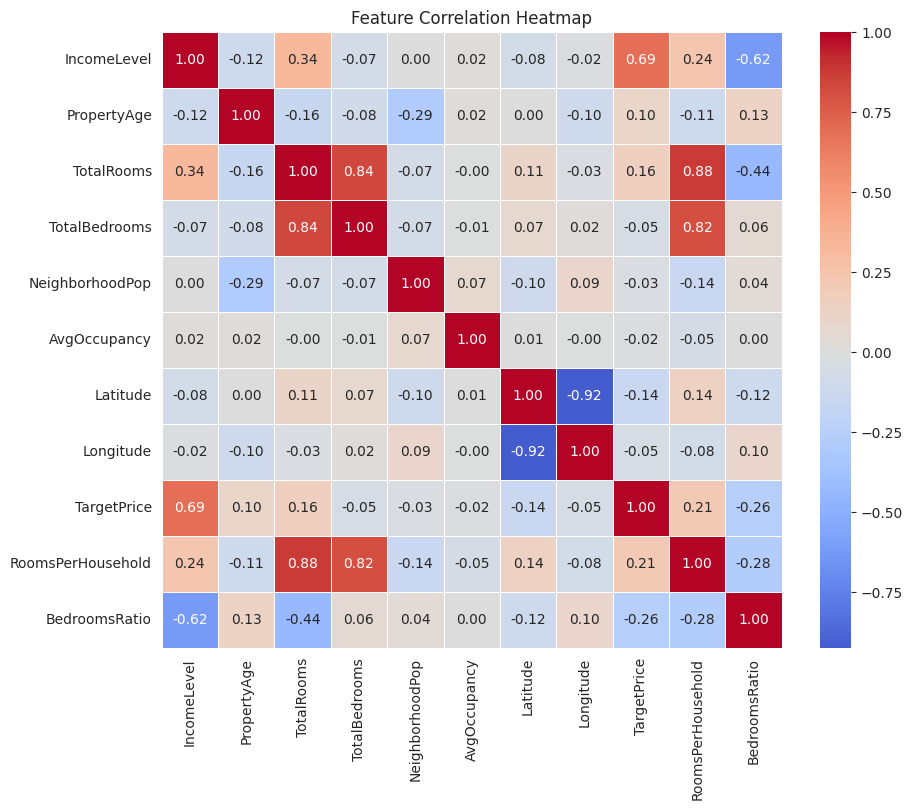


Top correlations with TargetPrice:
TargetPrice          1.000000
IncomeLevel          0.690538
RoomsPerHousehold    0.212915
TotalRooms           0.158177
PropertyAge          0.101565
AvgOccupancy        -0.022110
NeighborhoodPop     -0.025969
Longitude           -0.046349
TotalBedrooms       -0.051315
Latitude            -0.142983
BedroomsRatio       -0.257419
Name: TargetPrice, dtype: float64


In [7]:
# ══════════════════════════════════════════════════════════════════
# 5. CORRELATION HEATMAP
# ══════════════════════════════════════════════════════════════════
plt.figure(figsize=(10, 8))
corr = train.drop(columns=[ID_COL]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

print("\nTop correlations with TargetPrice:")
print(corr[TARGET].sort_values(ascending=False))

### 💡 Insight — Correlation Analysis
`IncomeLevel` is by far the strongest predictor of `TargetPrice` (**r = 0.69**), consistent with real-world housing economics. `RoomsPerHousehold` (0.21) and `TotalRooms` (0.16) show weaker positive relationships. Interestingly, `BedroomsRatio` has the strongest *negative* correlation (**r = -0.26**) — districts with a higher proportion of bedrooms to total rooms tend to have lower home values, possibly reflecting smaller/older housing stock. Raw `AvgOccupancy` and `NeighborhoodPop` show almost no linear correlation with price (-0.02 each), suggesting any predictive value they add is likely non-linear — which tree-based models like LightGBM can still capture even though a linear correlation coefficient misses it.